# Topology Optimization of Binary Structures (TOBS)
## Transformer flux maximization - Coarse / Fine / Corrective-Coarse mesh study

**Reference:**  
> Sivapuram, R., & Picelli, R. (2018).  
> *Topology optimization of binary structures using Integer Linear Programming.*  
> Finite Elements in Analysis and Design, 139, 49-61.  

---

### What is TOBS?

TOBS is a **discrete 0/1 optimization** method.  
Each element is either **material (1)** or **void (0)** — no intermediate grey values.  
At every iteration TOBS solves an **Integer Linear Program (ILP)**:

$$
\min_{\mathbf{x} \in \{0,1\}^N} \quad \mathbf{s}^\top \mathbf{x}
\quad \text{s.t.} \quad \mathbf{v}^\top \mathbf{x} \leq V^*, \quad |\mathbf{x} - \mathbf{x}^{(k)}|_1 \leq \Delta
$$

The ILP is solved by LP-relaxation (the constraint matrix is totally unimodular,
so the LP solution is automatically integer-valued).

---

### Notebook structure

| Section | Mesh `maxh` | Initialisation |
|---------|------------|----------------|
| A | 0.5 (coarse) | uniform void |
| B | 0.05 (fine) | uniform void |
| C | 0.5 (coarse) | projected from fine-mesh result |

Section C answers: *does the fine-mesh optimum provide a better warm-start for the coarse problem?*

## 0) Shared setup - imports, physics helpers, TOBS solver

In [1]:
###############################################################################
## SHARED SETUP : physics helpers and TOBS LP solver
## All mesh-dependent functions take mesh as an explicit argument.
###############################################################################

from numpy import pi
import numpy as np
import matplotlib.pyplot as plt

from ngsolve import (CF, grad, H1, L2, BilinearForm, LinearForm,
                     GridFunction, Integrate, dx, VOL)
from ngsolve.webgui import Draw
from scipy.optimize import linprog
from scipy.sparse  import hstack, vstack, eye, csr_matrix
from scipy.spatial import KDTree

from geometry     import transformer
from solver       import solve, flux, curl
from optimization import solve_adjoint

# Physical constants
mu0  = 4e-7 * pi   # permeability of free space (H/m)
mur  = 1000        # relative permeability of iron
j    = 1e6         # primary coil current density (A/m^2)
dnu_drho = CF(1/(mu0*mur) - 1/mu0)   # d(nu)/d(rho) for p=1

def nu(rho, p=1):
    # Reluctivity as a function of density (power-law SIMP interpolation).
    return 1/mu0 + rho**p * (1/(mu0*mur) - 1/mu0)

def state(rho, mesh):
    # Solve magnetostatic state equation for density field rho on mesh.
    fes = H1(mesh, order=1, dirichlet='dOmega')
    a, v = fes.TnT()
    bf = BilinearForm(curl(v) * (nu(rho) * curl(a)) * dx)
    lf = LinearForm(j * v * dx('Pp') - j * v * dx('Pm'))
    return solve(bf, lf)

def f(sol):
    # Objective to minimise: negative secondary flux.
    return -flux(sol)

def df(a, rho, aStar):
    # Adjoint right-hand side.
    return aStar*dx('Sm') - aStar*dx('Sp')

def f_prime(state_gf, adjoint_gf, rho):
    # Assemble elemental sensitivity linear form.
    fes  = rho.space
    drho = fes.TestFunction()
    lform = LinearForm(fes)
    lform += curl(adjoint_gf) * (dnu_drho * curl(state_gf)) * drho * dx
    lform.Assemble()
    return lform

def f_derivative(a_rho, rho, Kinv):
    # Full sensitivity GridFunction (adjoint + chain rule).
    p_rho   = solve_adjoint(a_rho, rho, Kinv, df)
    grad_gf = GridFunction(rho.space)
    grad_gf.vec.data = f_prime(a_rho, p_rho, rho).vec
    return grad_gf

def compute_sensitivity(rho, mesh):
    # Run FEA; return (objective_scalar, sensitivity_array, state_gf).
    u, Kinv  = state(rho, mesh)
    obj_val  = f(u)
    sens_gf  = f_derivative(u, rho, Kinv)
    sens_vec = sens_gf.vec.FV().NumPy()[:].copy()
    return obj_val, sens_vec, u

def m(rho, mesh, zone='Omega_c'):
    # Volume fraction of rho over the design domain.
    return (Integrate(rho*dx(zone), mesh)
            / Integrate(1, mesh, definedon=mesh.Materials(zone)))

def tobs_update(x_current, sens, eVol, V_target, delta):
    # Solve LP:  min s^T x  s.t.  v^T x <= V_target,  ||x-x0||_1 <= delta.
    # Constraint matrix is TU so LP solution is automatically integer-valued.
    N  = len(x_current)
    x0 = x_current.copy()
    c  = np.concatenate([sens, np.zeros(N)])
    I  = eye(N, format='csr')
    eV = csr_matrix(eVol.reshape(1, N))
    A_vol  = hstack([eV,                 csr_matrix((1, N))])
    A_move = hstack([csr_matrix((1, N)), csr_matrix(np.ones((1, N)))])
    A_t1   = hstack([ I, -I])
    A_t2   = hstack([-I, -I])
    A_ub = vstack([A_vol, A_move, A_t1, A_t2], format='csc')
    b_ub = np.concatenate([[V_target], [float(delta)], x0, -x0])
    bounds = [(0, 1)] * N + [(0, None)] * N
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    if not res.success:
        raise RuntimeError(f'LP failed: {res.message}')
    return np.round(res.x[:N]).astype(float)

def build_mesh_data(mesh):
    # Return (mask, eVol, N_design, rho_gf) for a given mesh.
    # mask  : boolean array True inside Omega_c
    # eVol  : normalised element volumes for design-domain elements
    V0  = Integrate(1, mesh, definedon=mesh.Materials('Omega_c'))
    gf  = GridFunction(L2(mesh, definedon=mesh.Materials('Omega_c')))
    gf.Set(1)
    mask = gf.vec.FV().NumPy()[:] >= 0.9
    N    = int(np.sum(mask))
    eVol_all = Integrate(1, mesh, definedon=mesh.Materials('Omega_c'),
                         element_wise=True).NumPy()[:] / V0
    eVol = eVol_all[mask]
    rho = GridFunction(L2(mesh, definedon='Omega_c'))
    return mask, eVol, N, rho

def element_centroids(msh, zone='Omega_c'):
    # Return (N_zone, 2) array of element centroids in the design domain.
    pts = []
    for el in msh.Elements(VOL):
        if msh[el].mat == zone:
            verts = [msh[v].point for v in msh[el].vertices]
            cx = sum(pp[0] for pp in verts) / len(verts)
            cy = sum(pp[1] for pp in verts) / len(verts)
            pts.append([cx, cy])
    return np.array(pts)

print("Shared setup complete.")

Shared setup complete.


---
## Section A - Coarse Mesh (maxh = 0.5)

Run TOBS from a uniform void initialisation on the **coarse** mesh.  
Fast but low resolution - serves as the cold-start baseline.

In [2]:
###############################################################################
## A-1 : Build coarse mesh (maxh = 0.5) and display
###############################################################################

mesh_coarse = transformer(maxh=0.5)
print(f"Region names : {mesh_coarse.GetMaterials()}")
print(f"Line names   : {mesh_coarse.GetBoundaries()}")
Draw(mesh_coarse)

Region names : ('Omega_c', 'Pp', 'Pm', 'Sm', 'Sp')
Line names   : ('dOmega', 'dOmega', 'dOmega', 'dOmega', 'dPp', 'dPp', 'dPp', 'dPp', 'dPm', 'dPm', 'dPm', 'dPm', 'dSm', 'dSm', 'dSm', 'dSm', 'dSp', 'dSp', 'dSp', 'dSp')


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

In [3]:
###############################################################################
## A-2 : Mesh data and design-variable initialisation (uniform void)
###############################################################################

mask_c, eVol_c, N_c, rho_c = build_mesh_data(mesh_coarse)
xval_c = np.zeros(N_c)
rho_c.vec.data.FV().NumPy()[mask_c] = xval_c

print(f"Coarse mesh -- design elements : {N_c}")
print(f"Sum of normalised volumes      : {eVol_c.sum():.4f}  (should be approx 1)")

Coarse mesh -- design elements : 508
Sum of normalised volumes      : 1.0000  (should be approx 1)


In [4]:
###############################################################################
## A-3 : TOBS hyperparameters -- coarse mesh
###############################################################################

V_target_c   = 0.10      # 10% iron volume fraction
delta_frac_c = 0.05      # 5% of elements may switch per iteration
delta_c      = max(1, int(delta_frac_c * N_c))
N_max_c      = 100
patience_c   = 5

print(f"Volume target  : {V_target_c*100:.1f}%")
print(f"Move limit D   : {delta_c} elements/iter  ({delta_frac_c*100:.0f}% of {N_c})")

Volume target  : 10.0%
Move limit D   : 25 elements/iter  (5% of 508)


In [5]:
###############################################################################
## A-4 : TOBS optimisation loop -- coarse mesh
###############################################################################

scene_c = Draw(rho_c, mesh_coarse, min=0, max=1)

MemObj_c = []; MemVol_c = []; MemSw_c = []
sens_prev_c  = None
no_change_c  = 0

print("Starting TOBS (coarse mesh) ...")
print(f"{'Iter':>5} | {'Objective':>12} | {'Volume %':>9} | {'Switches':>9}")
print("-" * 46)

for loop in range(1, N_max_c + 1):
    obj_val, sens_all, u_c = compute_sensitivity(rho_c, mesh_coarse)
    sens = sens_all[mask_c]

    sens_avg = 0.5*(sens + sens_prev_c) if sens_prev_c is not None else sens.copy()
    sens_prev_c = sens.copy()

    current_vol = float(np.dot(eVol_c, xval_c))
    MemObj_c.append(obj_val); MemVol_c.append(current_vol)

    xval_c_new = tobs_update(xval_c, sens_avg, eVol_c, V_target_c, delta_c)
    n_sw = int(np.sum(xval_c_new != xval_c))
    MemSw_c.append(n_sw)

    xval_c = xval_c_new.copy()
    rho_c.vec.data.FV().NumPy()[mask_c] = xval_c
    scene_c.Redraw()

    print(f"{loop:5d} | {obj_val:12.5e} | {current_vol*100:9.2f} | {n_sw:9d}")

    if n_sw == 0:
        no_change_c += 1
        if no_change_c >= patience_c:
            print(f"\nConverged: no element switched for {patience_c} consecutive iterations.")
            break
    else:
        no_change_c = 0

u_final_c, _ = state(rho_c, mesh_coarse)
print(f"\nTOBS (coarse) finished after {loop} iterations.")
print(f"Final flux  = {flux(u_final_c):.5e} Wb/m")
print(f"Final vol   = {m(rho_c, mesh_coarse)*100:.3f}%")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

Starting TOBS (coarse mesh) ...
 Iter |    Objective |  Volume % |  Switches
----------------------------------------------
    1 | -4.97221e+00 |      0.00 |        25
    2 | -1.20082e+01 |      5.64 |        25
    3 | -2.60347e+01 |      9.88 |        15
    4 | -3.40039e+01 |     10.02 |         4
    5 | -3.76233e+01 |      9.99 |         8
    6 | -4.48549e+01 |      9.93 |         0
    7 | -4.48549e+01 |      9.93 |         0
    8 | -4.48549e+01 |      9.93 |         0
    9 | -4.48549e+01 |      9.93 |         0
   10 | -4.48549e+01 |      9.93 |         0

Converged: no element switched for 5 consecutive iterations.

TOBS (coarse) finished after 10 iterations.
Final flux  = 4.48549e+01 Wb/m
Final vol   = 9.934%


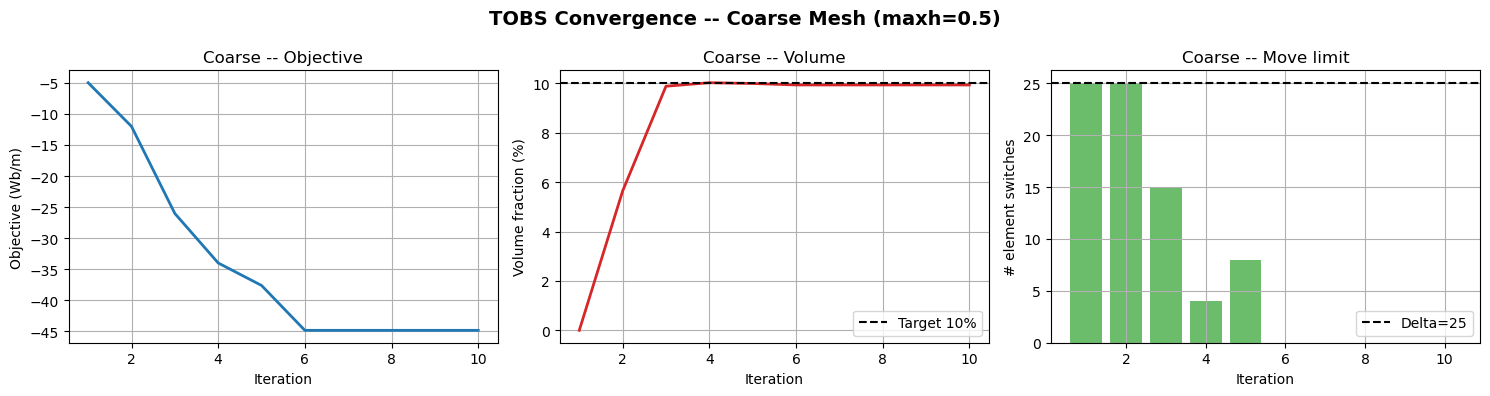

In [6]:
###############################################################################
## A-5 : Convergence plots -- coarse mesh
###############################################################################

iters_c = np.arange(1, len(MemObj_c) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(iters_c, MemObj_c, color='tab:blue', lw=2)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Objective (Wb/m)")
axes[0].set_title("Coarse -- Objective"); axes[0].grid(True)

axes[1].plot(iters_c, [v*100 for v in MemVol_c], color='tab:red', lw=2)
axes[1].axhline(V_target_c*100, color='k', ls='--', label=f'Target {V_target_c*100:.0f}%')
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Volume fraction (%)")
axes[1].set_title("Coarse -- Volume"); axes[1].legend(); axes[1].grid(True)

axes[2].bar(iters_c, MemSw_c, color='tab:green', alpha=0.7)
axes[2].axhline(delta_c, color='k', ls='--', label=f'Delta={delta_c}')
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("# element switches")
axes[2].set_title("Coarse -- Move limit"); axes[2].legend(); axes[2].grid(True)

plt.suptitle('TOBS Convergence -- Coarse Mesh (maxh=0.5)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [7]:
###############################################################################
## A-6 : Final topology -- coarse mesh
###############################################################################

print("-- Coarse mesh: final binary topology --")
Draw(rho_c, mesh_coarse, min=0, max=1)

-- Coarse mesh: final binary topology --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

---
## Section B - Fine Mesh (maxh = 0.05)

Run TOBS from a uniform void initialisation on the **fine** mesh.  
High resolution - gives the reference optimum; more elements, longer per iteration.

In [8]:
###############################################################################
## B-1 : Build fine mesh (maxh = 0.05) and display
###############################################################################

mesh_fine = transformer(maxh=0.05)
print(f"Region names : {mesh_fine.GetMaterials()}")
print(f"Line names   : {mesh_fine.GetBoundaries()}")
Draw(mesh_fine)

Region names : ('Omega_c', 'Pp', 'Pm', 'Sm', 'Sp')
Line names   : ('dOmega', 'dOmega', 'dOmega', 'dOmega', 'dPp', 'dPp', 'dPp', 'dPp', 'dPm', 'dPm', 'dPm', 'dPm', 'dSm', 'dSm', 'dSm', 'dSm', 'dSp', 'dSp', 'dSp', 'dSp')


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

In [9]:
###############################################################################
## B-2 : Mesh data and design-variable initialisation (uniform void)
###############################################################################

mask_f, eVol_f, N_f, rho_f = build_mesh_data(mesh_fine)
xval_f = np.zeros(N_f)
rho_f.vec.data.FV().NumPy()[mask_f] = xval_f

print(f"Fine mesh -- design elements : {N_f}")
print(f"Sum of normalised volumes    : {eVol_f.sum():.4f}  (should be approx 1)")

Fine mesh -- design elements : 49214
Sum of normalised volumes    : 1.0000  (should be approx 1)


In [10]:
###############################################################################
## B-3 : TOBS hyperparameters -- fine mesh
###############################################################################

V_target_f   = 0.10
delta_frac_f = 0.05
delta_f      = max(1, int(delta_frac_f * N_f))
N_max_f      = 100
patience_f   = 5

print(f"Volume target  : {V_target_f*100:.1f}%")
print(f"Move limit D   : {delta_f} elements/iter  ({delta_frac_f*100:.0f}% of {N_f})")

Volume target  : 10.0%
Move limit D   : 2460 elements/iter  (5% of 49214)


In [11]:
###############################################################################
## B-4 : TOBS optimisation loop -- fine mesh
###############################################################################

scene_f = Draw(rho_f, mesh_fine, min=0, max=1)

MemObj_f = []; MemVol_f = []; MemSw_f = []
sens_prev_f = None
no_change_f = 0

print("Starting TOBS (fine mesh) ...")
print(f"{'Iter':>5} | {'Objective':>12} | {'Volume %':>9} | {'Switches':>9}")
print("-" * 46)

for loop in range(1, N_max_f + 1):
    obj_val, sens_all, u_f = compute_sensitivity(rho_f, mesh_fine)
    sens = sens_all[mask_f]

    sens_avg = 0.5*(sens + sens_prev_f) if sens_prev_f is not None else sens.copy()
    sens_prev_f = sens.copy()

    current_vol = float(np.dot(eVol_f, xval_f))
    MemObj_f.append(obj_val); MemVol_f.append(current_vol)

    xval_f_new = tobs_update(xval_f, sens_avg, eVol_f, V_target_f, delta_f)
    n_sw = int(np.sum(xval_f_new != xval_f))
    MemSw_f.append(n_sw)

    xval_f = xval_f_new.copy()
    rho_f.vec.data.FV().NumPy()[mask_f] = xval_f
    scene_f.Redraw()

    print(f"{loop:5d} | {obj_val:12.5e} | {current_vol*100:9.2f} | {n_sw:9d}")

    if n_sw == 0:
        no_change_f += 1
        if no_change_f >= patience_f:
            print(f"\nConverged: no element switched for {patience_f} consecutive iterations.")
            break
    else:
        no_change_f = 0

u_final_f, _ = state(rho_f, mesh_fine)
print(f"\nTOBS (fine) finished after {loop} iterations.")
print(f"Final flux  = {flux(u_final_f):.5e} Wb/m")
print(f"Final vol   = {m(rho_f, mesh_fine)*100:.3f}%")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

Starting TOBS (fine mesh) ...
 Iter |    Objective |  Volume % |  Switches
----------------------------------------------
    1 | -4.98299e+00 |      0.00 |      2460
    2 | -1.61573e+01 |      4.78 |      2460
    3 | -4.36156e+01 |      9.98 |       392
    4 | -5.37577e+01 |     10.00 |       101
    5 | -5.80293e+01 |     10.00 |        68
    6 | -6.06616e+01 |     10.00 |        72
    7 | -6.35838e+01 |     10.00 |        56
    8 | -6.59964e+01 |     10.00 |        51
    9 | -6.83772e+01 |     10.00 |        45
   10 | -7.08760e+01 |     10.00 |        44
   11 | -7.34852e+01 |     10.00 |        42
   12 | -7.61420e+01 |     10.00 |        37
   13 | -7.86628e+01 |     10.00 |        35
   14 | -8.12239e+01 |     10.00 |        33
   15 | -8.39784e+01 |     10.00 |        30
   16 | -8.65523e+01 |     10.00 |        26
   17 | -8.88455e+01 |     10.00 |        28
   18 | -9.15734e+01 |     10.00 |        25
   19 | -9.40094e+01 |     10.00 |        23
   20 | -9.65369e+01 | 

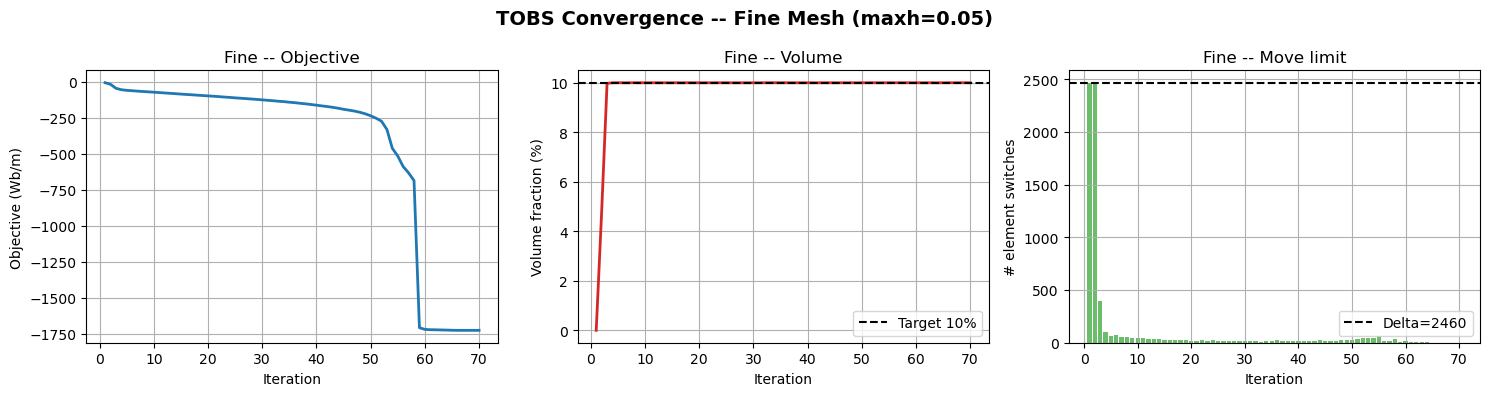

In [12]:
###############################################################################
## B-5 : Convergence plots -- fine mesh
###############################################################################

iters_f = np.arange(1, len(MemObj_f) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(iters_f, MemObj_f, color='tab:blue', lw=2)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Objective (Wb/m)")
axes[0].set_title("Fine -- Objective"); axes[0].grid(True)

axes[1].plot(iters_f, [v*100 for v in MemVol_f], color='tab:red', lw=2)
axes[1].axhline(V_target_f*100, color='k', ls='--', label=f'Target {V_target_f*100:.0f}%')
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Volume fraction (%)")
axes[1].set_title("Fine -- Volume"); axes[1].legend(); axes[1].grid(True)

axes[2].bar(iters_f, MemSw_f, color='tab:green', alpha=0.7)
axes[2].axhline(delta_f, color='k', ls='--', label=f'Delta={delta_f}')
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("# element switches")
axes[2].set_title("Fine -- Move limit"); axes[2].legend(); axes[2].grid(True)

plt.suptitle('TOBS Convergence -- Fine Mesh (maxh=0.05)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
###############################################################################
## B-6 : Final topology -- fine mesh
###############################################################################

print("-- Fine mesh: final binary topology --")
Draw(rho_f, mesh_fine, min=0, max=1)

-- Fine mesh: final binary topology --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

---
## Section C - Corrective Coarse Mesh

### Idea
The fine-mesh optimum is a high-resolution description of *where* material should go.  
We **project** that binary topology back onto the coarse mesh via a nearest-centroid  
mapping and use it as a warm-start initialisation, then re-run TOBS on the coarse mesh.

**Projection rule (nearest centroid):**  
For each coarse element centroid, find the fine element whose centroid is closest  
and inherit its binary density value (0 or 1).

```
fine_centroids   -> KDTree
coarse_centroids -> query KDTree -> index array -> xval_fine[index]
```

**What to observe:**
- Does it converge in fewer iterations than the cold-start coarse run (Section A)?
- Does it reach a better or worse final objective?
- How closely does the projected initialisation already satisfy the volume constraint?

In [14]:
###############################################################################
## C-1 : Project fine-mesh result onto coarse mesh (nearest centroid)
###############################################################################

# Centroids of design-domain elements on each mesh
fine_centroids   = element_centroids(mesh_fine,   zone='Omega_c')
coarse_centroids = element_centroids(mesh_coarse, zone='Omega_c')

# For every coarse element, find the nearest fine element
tree   = KDTree(fine_centroids)
_, idx = tree.query(coarse_centroids)            # shape: (N_c,)
xval_cc_init = np.round(xval_f[idx]).astype(float)  # inherit fine binary density

# Initialise corrective coarse GridFunction from projected densities
mask_cc, eVol_cc, N_cc, rho_cc = build_mesh_data(mesh_coarse)
xval_cc = xval_cc_init.copy()
rho_cc.vec.data.FV().NumPy()[mask_cc] = xval_cc

proj_vol = float(np.dot(eVol_cc, xval_cc))
print(f"Corrective coarse -- design elements     : {N_cc}")
print(f"Projected volume fraction                : {proj_vol*100:.2f}%  (target: 10%)")
print("\n-- Warm-start (projected) topology on coarse mesh --")
Draw(rho_cc, mesh_coarse, min=0, max=1)

Corrective coarse -- design elements     : 508
Projected volume fraction                : 9.75%  (target: 10%)

-- Warm-start (projected) topology on coarse mesh --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

In [15]:
###############################################################################
## C-2 : TOBS hyperparameters -- corrective coarse mesh
###############################################################################

V_target_cc   = 0.10
delta_frac_cc = 0.05
delta_cc      = max(1, int(delta_frac_cc * N_cc))
N_max_cc      = 100
patience_cc   = 5

print(f"Volume target  : {V_target_cc*100:.1f}%")
print(f"Move limit D   : {delta_cc} elements/iter  ({delta_frac_cc*100:.0f}% of {N_cc})")

Volume target  : 10.0%
Move limit D   : 25 elements/iter  (5% of 508)


In [16]:
###############################################################################
## C-3 : TOBS optimisation loop -- corrective coarse mesh
###############################################################################

scene_cc = Draw(rho_cc, mesh_coarse, min=0, max=1)

MemObj_cc = []; MemVol_cc = []; MemSw_cc = []
sens_prev_cc = None
no_change_cc = 0

print("Starting TOBS (corrective coarse mesh) ...")
print(f"{'Iter':>5} | {'Objective':>12} | {'Volume %':>9} | {'Switches':>9}")
print("-" * 46)

for loop in range(1, N_max_cc + 1):
    obj_val, sens_all, u_cc = compute_sensitivity(rho_cc, mesh_coarse)
    sens = sens_all[mask_cc]

    sens_avg = 0.5*(sens + sens_prev_cc) if sens_prev_cc is not None else sens.copy()
    sens_prev_cc = sens.copy()

    current_vol = float(np.dot(eVol_cc, xval_cc))
    MemObj_cc.append(obj_val); MemVol_cc.append(current_vol)

    xval_cc_new = tobs_update(xval_cc, sens_avg, eVol_cc, V_target_cc, delta_cc)
    n_sw = int(np.sum(xval_cc_new != xval_cc))
    MemSw_cc.append(n_sw)

    xval_cc = xval_cc_new.copy()
    rho_cc.vec.data.FV().NumPy()[mask_cc] = xval_cc
    scene_cc.Redraw()

    print(f"{loop:5d} | {obj_val:12.5e} | {current_vol*100:9.2f} | {n_sw:9d}")

    if n_sw == 0:
        no_change_cc += 1
        if no_change_cc >= patience_cc:
            print(f"\nConverged: no element switched for {patience_cc} consecutive iterations.")
            break
    else:
        no_change_cc = 0

u_final_cc, _ = state(rho_cc, mesh_coarse)
print(f"\nTOBS (corrective coarse) finished after {loop} iterations.")
print(f"Final flux  = {flux(u_final_cc):.5e} Wb/m")
print(f"Final vol   = {m(rho_cc, mesh_coarse)*100:.3f}%")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

Starting TOBS (corrective coarse mesh) ...
 Iter |    Objective |  Volume % |  Switches
----------------------------------------------
    1 | -3.12386e+01 |      9.75 |         9
    2 | -4.01121e+01 |      9.96 |         4
    3 | -4.26545e+01 |      9.92 |         4
    4 | -4.81492e+01 |      9.90 |         1
    5 | -5.04965e+01 |     10.08 |         0
    6 | -5.04965e+01 |     10.08 |         0
    7 | -5.04965e+01 |     10.08 |         0
    8 | -5.04965e+01 |     10.08 |         0
    9 | -5.04965e+01 |     10.08 |         0

Converged: no element switched for 5 consecutive iterations.

TOBS (corrective coarse) finished after 9 iterations.
Final flux  = 5.04965e+01 Wb/m
Final vol   = 10.078%


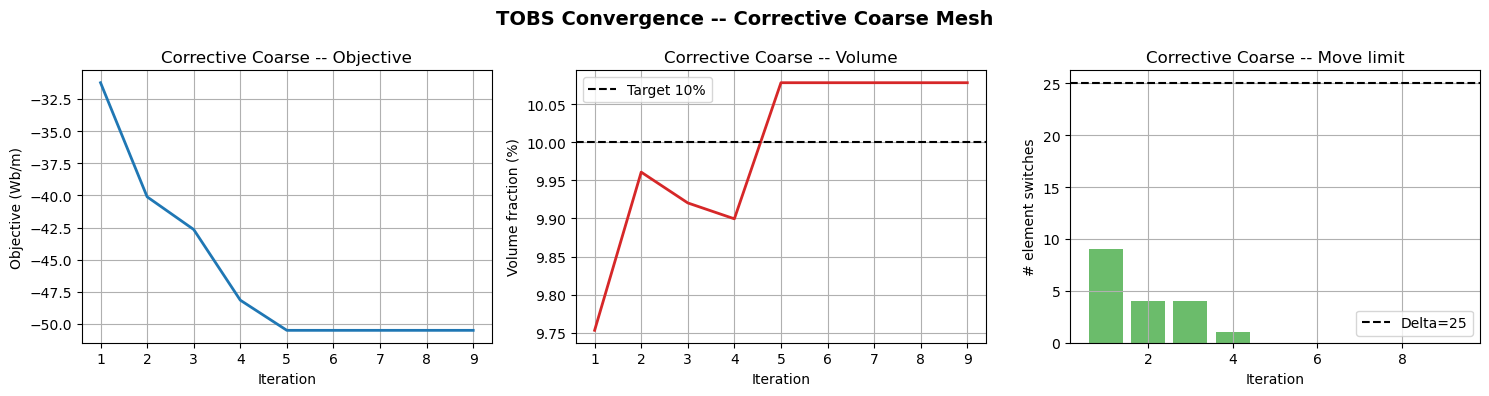

In [17]:
###############################################################################
## C-4 : Convergence plots -- corrective coarse mesh
###############################################################################

iters_cc = np.arange(1, len(MemObj_cc) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(iters_cc, MemObj_cc, color='tab:blue', lw=2)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Objective (Wb/m)")
axes[0].set_title("Corrective Coarse -- Objective"); axes[0].grid(True)

axes[1].plot(iters_cc, [v*100 for v in MemVol_cc], color='tab:red', lw=2)
axes[1].axhline(V_target_cc*100, color='k', ls='--', label=f'Target {V_target_cc*100:.0f}%')
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Volume fraction (%)")
axes[1].set_title("Corrective Coarse -- Volume"); axes[1].legend(); axes[1].grid(True)

axes[2].bar(iters_cc, MemSw_cc, color='tab:green', alpha=0.7)
axes[2].axhline(delta_cc, color='k', ls='--', label=f'Delta={delta_cc}')
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("# element switches")
axes[2].set_title("Corrective Coarse -- Move limit"); axes[2].legend(); axes[2].grid(True)

plt.suptitle('TOBS Convergence -- Corrective Coarse Mesh', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [18]:
###############################################################################
## C-5 : Final topology -- corrective coarse mesh
###############################################################################

print("-- Corrective coarse mesh: final binary topology --")
Draw(rho_cc, mesh_coarse, min=0, max=1)

-- Corrective coarse mesh: final binary topology --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

---
## Section D - Three-way comparison

Overlay convergence curves for all three runs and print a summary table.

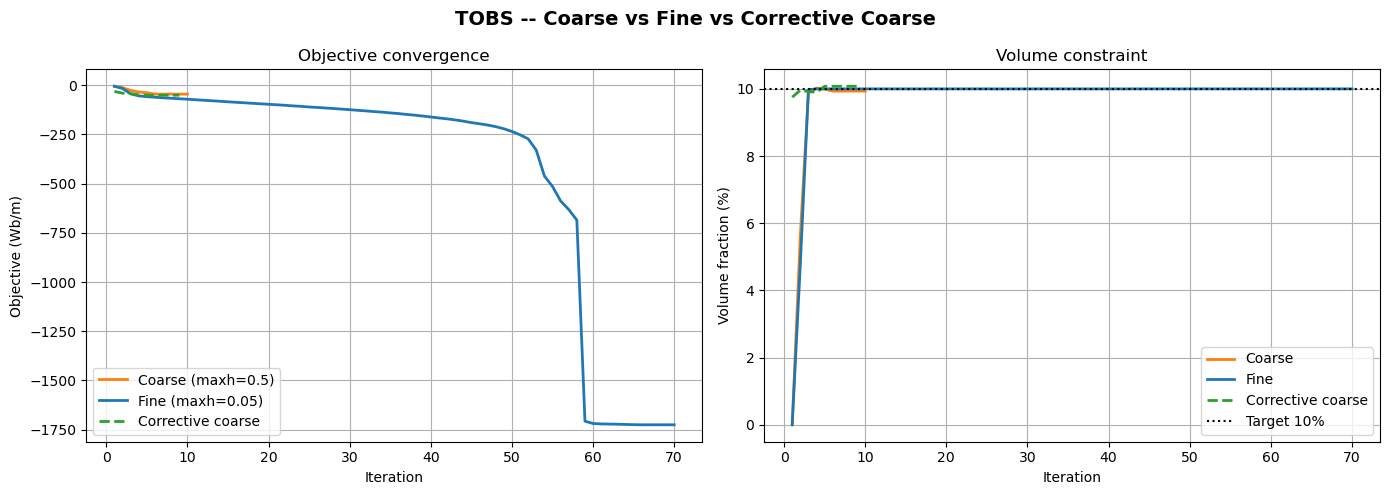


Run                         Iters     Final flux (Wb/m)     Vol %
Coarse (maxh=0.5)              10           4.48549e+01     9.934
Fine   (maxh=0.05)             70           1.72527e+03    10.001
Corrective coarse               9           5.04965e+01    10.078


In [19]:
###############################################################################
## D-1 : Overlay convergence curves -- objective and volume fraction
###############################################################################

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Objective
axes[0].plot(np.arange(1, len(MemObj_c)  + 1), MemObj_c,
             color='tab:orange', lw=2,              label='Coarse (maxh=0.5)')
axes[0].plot(np.arange(1, len(MemObj_f)  + 1), MemObj_f,
             color='tab:blue',   lw=2,              label='Fine (maxh=0.05)')
axes[0].plot(np.arange(1, len(MemObj_cc) + 1), MemObj_cc,
             color='tab:green',  lw=2, ls='--',     label='Corrective coarse')
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Objective (Wb/m)")
axes[0].set_title("Objective convergence"); axes[0].legend(); axes[0].grid(True)

# Volume fraction
axes[1].plot(np.arange(1, len(MemVol_c)  + 1), [v*100 for v in MemVol_c],
             color='tab:orange', lw=2,          label='Coarse')
axes[1].plot(np.arange(1, len(MemVol_f)  + 1), [v*100 for v in MemVol_f],
             color='tab:blue',   lw=2,          label='Fine')
axes[1].plot(np.arange(1, len(MemVol_cc) + 1), [v*100 for v in MemVol_cc],
             color='tab:green',  lw=2, ls='--', label='Corrective coarse')
axes[1].axhline(10, color='k', ls=':', label='Target 10%')
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Volume fraction (%)")
axes[1].set_title("Volume constraint"); axes[1].legend(); axes[1].grid(True)

plt.suptitle('TOBS -- Coarse vs Fine vs Corrective Coarse',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary table
print("\n" + "="*64)
print(f"{'Run':<26} {'Iters':>6}  {'Final flux (Wb/m)':>20}  {'Vol %':>8}")
print("="*64)
print(f"{'Coarse (maxh=0.5)':<26} {len(MemObj_c):>6}  "
      f"{flux(u_final_c):>20.5e}  {m(rho_c,  mesh_coarse)*100:>8.3f}")
print(f"{'Fine   (maxh=0.05)':<26} {len(MemObj_f):>6}  "
      f"{flux(u_final_f):>20.5e}  {m(rho_f,  mesh_fine)*100:>8.3f}")
print(f"{'Corrective coarse':<26} {len(MemObj_cc):>6}  "
      f"{flux(u_final_cc):>20.5e}  {m(rho_cc, mesh_coarse)*100:>8.3f}")
print("="*64)

In [20]:
###############################################################################
## D-2 : Final topologies side by side
###############################################################################

print("-- Coarse mesh: final topology --")
Draw(rho_c,  mesh_coarse, min=0, max=1)

print("-- Fine mesh: final topology --")
Draw(rho_f,  mesh_fine,   min=0, max=1)

print("-- Corrective coarse: final topology --")
Draw(rho_cc, mesh_coarse, min=0, max=1)

-- Coarse mesh: final topology --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

-- Fine mesh: final topology --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

-- Corrective coarse: final topology --


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene